In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
import zipfile
from collections import defaultdict
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'
total_files = os.listdir(data_path)

print("Total files are:", len(total_files))
wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt", "") for f in txt_files])
common_files = list(wav_set.intersection(txt_set))

print("Usable common files:", len(common_files))

train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files  = train_test_split(train_files, test_size=0.2, random_state=42)

In [17]:
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def time_shift(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def time_stretch(signal, rate=0.9):
    return librosa.effects.time_stretch(signal, rate=rate)

def pitch_shift(signal, sr=16000, n_steps=1):
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)

def augment_signal(signal, sr=16000):
    augmented = [signal] # Original basic pattern
    augmented.append(add_noise(signal))
    augmented.append(time_shift(signal))
    try:
        augmented.append(time_stretch(signal, rate=np.random.uniform(0.9, 1.1)))
    except:
        pass
    try:
        augmented.append(pitch_shift(signal, sr, n_steps=np.random.uniform(-1, 1)))
    except:
        pass
    return augmented

In [18]:
def build_segments(file_list, augment=False, return_ids=False):
    segments = []
    labels = []
    file_ids = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()
                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]
                if len(segment) < 1000:
                    continue

                # 4-class labeling mechanism
                if crackle == 0 and wheeze == 0:
                    label = 0  # Normal
                elif crackle == 1 and wheeze == 0:
                    label = 1  # Crackle
                elif crackle == 0 and wheeze == 1:
                    label = 2  # Wheeze
                else:
                    label = 3  # Both Crackle and Wheeze

                if augment:
                    aug_list = augment_signal(segment, sr)
                    for aug in aug_list:
                        segments.append(aug)
                        labels.append(label)
                        file_ids.append(file)
                else:
                    segments.append(segment)
                    labels.append(label)
                    file_ids.append(file)

    if return_ids:
        return segments, labels, file_ids
    return segments, labels


In [19]:
print("Segmenting and processing datasets...")
X_train, y_train = build_segments(train_files, augment=False) 
X_val, y_val     = build_segments(val_files, augment=False)
X_test, y_test, test_ids = build_segments(test_files, augment=False, return_ids=True)

file_true = {}
for label, fid in zip(y_test, test_ids):
    file_true[fid] = label

Segmenting and processing datasets...


In [20]:
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

def extract_statistical_pooling(signal):
    signal = signal.astype(np.float32)
    _, embeddings, _ = yamnet(signal)
    emb = embeddings.numpy()

    mean   = np.mean(emb, axis=0)
    std    = np.std(emb, axis=0)
    max_   = np.max(emb, axis=0)
    min_   = np.min(emb, axis=0)
    median = np.median(emb, axis=0)
    q25    = np.percentile(emb, 25, axis=0)
    q75    = np.percentile(emb, 75, axis=0)

    return np.concatenate([mean, std, max_, min_, median, q25, q75])    
    
def create_embedding_dataset(X, y):
    X_emb = []
    y_clean = []
    for seg, label in zip(X, y):
        try:
            emb = extract_statistical_pooling(seg)
            X_emb.append(emb)
            y_clean.append(label)
        except:
            continue
    return np.array(X_emb), np.array(y_clean)

In [21]:
X_train_emb, y_train = create_embedding_dataset(X_train, y_train)
X_val_emb, y_val     = create_embedding_dataset(X_val, y_val)
X_test_emb, y_test   = create_embedding_dataset(X_test, y_test)

In [22]:
def create_proposed_mlp(input_dim=7168):
    model = Sequential([
        Dense(2048, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(8, activation='relu'),
        Dropout(0.3),
        Dense(4, activation='softmax')
    ])
    return model

In [23]:
grid_configs = [
    {"batch_size": 16, "lr": 0.0001},
    {"batch_size": 32, "lr": 0.0001},
    {"batch_size": 16, "lr": 0.0002},
    {"batch_size": 32, "lr": 0.0002},
    {"batch_size": 16, "lr": 0.0003},
    {"batch_size": 32, "lr": 0.0003},
    {"batch_size": 16, "lr": 0.0004},
    {"batch_size": 32, "lr": 0.0004}
]

performance_records = []
best_acc = 0.0
best_model = None
best_history = None


for config in grid_configs:
    bs = config["batch_size"]
    lr = config["lr"]
    print(f"Testing Target Execution Layout -> Batch Size: {bs}, Learning Rate: {lr}")
    
    # Fresh structural model reset
    temp_model = create_proposed_mlp(input_dim=X_train_emb.shape[1])
    temp_model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Training Loop execution
    history = temp_model.fit(
        X_train_emb, y_train,
        validation_data=(X_val_emb, y_val),
        epochs=50, # Keep 50 for grid testing speed, can increase to 100 later
        batch_size=bs,
        verbose=0
    )
    
    # Inference generation
    y_pred_prob_temp = temp_model.predict(X_test_emb, verbose=0)
    
    # File level Top-K Weighted Aggregation Engine
    file_preds_temp = defaultdict(list)
    for prob, label, fid in zip(y_pred_prob_temp, y_test, test_ids):
        file_preds_temp[fid].append(prob)
        
    y_true_file_temp = []
    y_pred_file_temp = []
    
    for fid in file_preds_temp:
        probs = np.array(file_preds_temp[fid])
        conf = np.max(probs, axis=1)
        k = max(1, len(probs)//3)
        top_idx = np.argsort(conf)[-k:]
        top_probs = probs[top_idx]
        top_conf = conf[top_idx]
        weights = top_conf / np.sum(top_conf)
        final_prob = np.sum(top_probs * weights[:, None], axis=0)
        
        y_pred_file_temp.append(np.argmax(final_prob))
        y_true_file_temp.append(file_true[fid])
        
    # Standard Performance calculations
    acc = accuracy_score(y_true_file_temp, y_pred_file_temp)
    macro_f1 = f1_score(y_true_file_temp, y_pred_file_temp, average='macro')
    weighted_f1 = f1_score(y_true_file_temp, y_pred_file_temp, average='weighted')
    
    performance_records.append({
        "Batch Size": bs,
        "Learning Rate": lr,
        "Accuracy (File-Level)": f"{acc*100:.2f}%",
        "Macro F1": f"{macro_f1:.4f}",
        "Weighted F1": f"{weighted_f1:.4f}"
    })
    
    # Storing data for the absolute best layout
    if acc > best_acc:
        best_acc = acc
        best_model = temp_model
        best_history = history
        final_y_true = y_true_file_temp
        final_y_pred = y_pred_file_temp

Testing Target Execution Layout -> Batch Size: 16, Learning Rate: 0.0001
Testing Target Execution Layout -> Batch Size: 32, Learning Rate: 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing Target Execution Layout -> Batch Size: 16, Learning Rate: 0.0002


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing Target Execution Layout -> Batch Size: 32, Learning Rate: 0.0002


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing Target Execution Layout -> Batch Size: 16, Learning Rate: 0.0004


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing Target Execution Layout -> Batch Size: 32, Learning Rate: 0.0004


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Final Sensitivity Analysis Table:
|   Batch Size |   Learning Rate | Accuracy (File-Level)   |   Macro F1 |   Weighted F1 |
|-------------:|----------------:|:------------------------|-----------:|--------------:|
|           16 |          0.0001 | 63.59%                  |     0.3044 |        0.6165 |
|           32 |          0.0001 | 70.65%                  |     0.3794 |        0.6756 |
|           16 |          0.0002 | 69.02%                  |     0.3772 |        0.6561 |
|           32 |          0.0002 | 61.96%                  |     0.3287 |        0.6129 |
|           16 |          0.0003 | 64.67%                  |     0.3473 |        0.6157 |
|           32 |          0.0003 | 61.41%                  |     0.2956 |        0.5965 |
|           16 |          0.0004 | 63.04%                  |     0.4017 |        0.6356 |
|           32 |          0.0004 | 63.04%                  |     0.3405 |        0.6177 |

Generation Plots for Best Hyperparameter Performance Match...

C

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


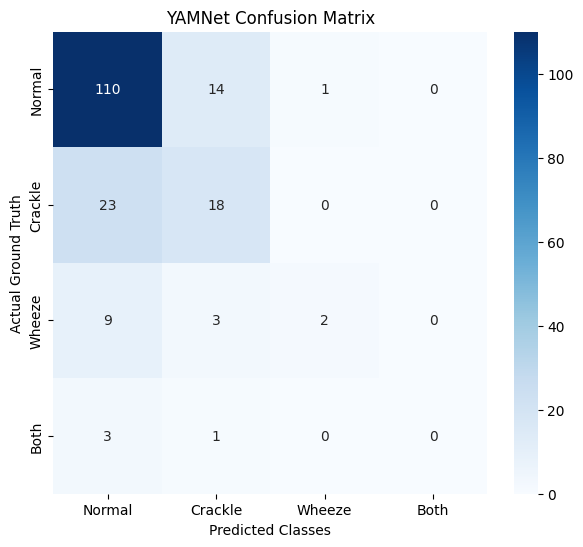

In [26]:
df_results = pd.DataFrame(performance_records)
print("\nFinal Sensitivity Analysis Table:")
print(df_results.to_markdown(index=False))


print("\nGeneration Plots for Best Hyperparameter Performance Match...")

print("\nClassification Report:")
print(classification_report(final_y_true, final_y_pred, target_names=["Normal", "Crackle", "Wheeze", "Both"]))

# Plot Confusion Matrix
cm = confusion_matrix(final_y_true, final_y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Normal", "Crackle", "Wheeze", "Both"],
            yticklabels=["Normal", "Crackle", "Wheeze", "Both"])
plt.title("YAMNet Confusion Matrix")
plt.xlabel("Predicted Classes")
plt.ylabel("Actual Ground Truth")
plt.show()